In [ ]:
#| hide
from programming_first_principles.core import prepare_notebook
from programming_first_principles.helpers.cost import Cost

In [ ]:
#| hide
prepare_notebook()

## Sorting 101

In [ ]:
scores = [40, 10, 35, 5, 80, 75, 5, 80]

#### Sorting by Selection

* Selection sort always does n(n − 1) / 2 comparisons. Swaps stay between 0 and n − 1.
* **sorted**, 0 swaps (min_element keeps the leftmost minimum, and a nondecreasing range already has it at i)
* **reversed, distinct values**: n − 1 swaps

In [ ]:
#| exports algorithms.sort
from programming_first_principles.algorithms.rearrange import swap
from programming_first_principles.algorithms.sort import min_element, is_sorted

def selection_sort(a, first, last):
    for i in range(first, last):
        m = min_element(a, i, last)
        if m != i:
            swap(a, i, m)

In [ ]:
scores = [40, 10, 35, 5, 80, 75, 5, 80]

a = scores.copy()
f'Before: {a = }, {is_sorted(a, 0, len(a)) = }'
selection_sort(a, 0, len(a))
f'After: {a = }, {is_sorted(a, 0, len(a)) = }'

sub = scores.copy()
f'Before: {sub = }'
selection_sort(sub, 2, 6)
f'After:  {sub = }'

'Before: a = [40, 10, 35, 5, 80, 75, 5, 80], is_sorted(a, 0, len(a)) = False'

'After: a = [5, 5, 10, 35, 40, 75, 80, 80], is_sorted(a, 0, len(a)) = True'

'Before: sub = [40, 10, 35, 5, 80, 75, 5, 80]'

'After:  sub = [40, 10, 5, 35, 75, 80, 5, 80]'

In [ ]:
sel = Cost(repeats=1)
_ = sel.run(selection_sort, scores.copy(), 0, len(scores),
        name='selection_sort', shape='scores',
        operations=('comparisons', 'swaps', 'ms'))
sel.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,selection_sort,scores,8,28,None,5,0.0057


In [ ]:
sel = Cost(repeats=3, sizes=(200, 400, 800))
sel.scale(selection_sort, operations=('comparisons', 'swaps', 'ms'))

,algo,shape,n,comparisons,predicates,swaps,ms
0,selection_sort,random,200,19900,None,193,1.2617
1,selection_sort,sorted,200,19900,None,0,1.1495
2,selection_sort,reversed,200,19900,None,101,1.3758
3,selection_sort,random,400,79800,None,388,4.3040
4,selection_sort,sorted,400,79800,None,0,3.6364
5,selection_sort,reversed,400,79800,None,208,4.3189
6,selection_sort,random,800,319600,None,794,14.7474
7,selection_sort,sorted,800,319600,None,0,13.7242
8,selection_sort,reversed,800,319600,None,412,15.0755


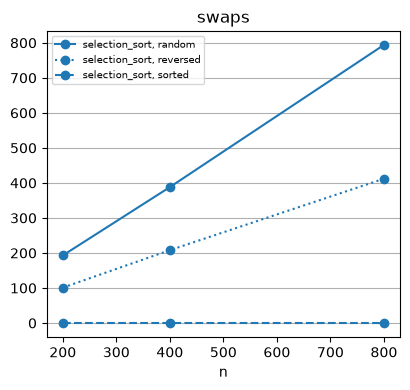

In [ ]:
sel.plot('swaps')

#### Sorting by Insertion

In [ ]:
#| exports algorithms.sort
from programming_first_principles.algorithms.rearrange import rotate
from bisect import bisect_right
def insertion_sort(a, first, last):
    for i in range(first + 1, last):
        at = bisect_right(a, a[i], first, i)
        if at != i:
            rotate(a, at, i, i + 1)

In [ ]:
b = scores.copy()
f'Before: {b = }, {is_sorted(b, 0, len(b)) = }'
insertion_sort(b, 0, len(b))
f'After:  {b = }, {is_sorted(b, 0, len(b)) = }'

'Before: b = [40, 10, 35, 5, 80, 75, 5, 80], is_sorted(b, 0, len(b)) = False'

'After:  b = [5, 5, 10, 35, 40, 75, 80, 80], is_sorted(b, 0, len(b)) = True'

In [ ]:
ins = Cost(repeats=1)
_ = ins.run(insertion_sort, scores.copy(), 0, len(scores),
        name='insertion_sort', shape='scores',
        operations=('comparisons', 'swaps', 'ms'))
ins.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,insertion_sort,scores,8,16,None,11,0.0057


In [ ]:
ins_scale = Cost(repeats=1, sizes=(200, 400, 800))
_ = ins_scale.scale(insertion_sort, operations=('comparisons', 'swaps', 'ms'))
ins_scale.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,insertion_sort,random,200,1255,None,10508,0.9712
1,insertion_sort,sorted,200,1153,None,0,0.0200
2,insertion_sort,reversed,200,1345,None,19898,1.6368
3,insertion_sort,random,400,2906,None,39980,2.6866
4,insertion_sort,sorted,400,2698,None,0,0.0393
5,insertion_sort,reversed,400,3089,None,79785,4.9702
6,insertion_sort,random,800,6603,None,157799,11.2039
7,insertion_sort,sorted,800,6187,None,0,0.0846
8,insertion_sort,reversed,800,6976,None,319575,20.6353


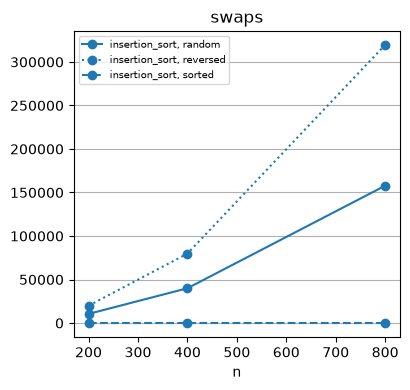

In [ ]:
ins_scale.plot('swaps')

#### Merge

In [ ]:
#| exports algorithms.sort
from programming_first_principles.ordering import in_order

def merge(left, right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if in_order(left[i], right[j]):
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result

In [ ]:
f'{merge([10, 35, 40, 80], [5, 5, 75, 80]) = }'

'merge([10, 35, 40, 80], [5, 5, 75, 80]) = [5, 5, 10, 35, 40, 75, 80, 80]'

In [ ]:
def merge_halves(a, mid):
    return merge(a[:mid], a[mid:])

m = Cost(repeats=1)
_ = m.run(merge_halves, [10, 35, 40, 80, 5, 5, 75, 80], 4,
          name='merge', shape='two sorted halves',
          operations=('comparisons', 'swaps', 'ms'))
m.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,merge,two sorted halves,8,7,None,0,0.0045


#### Mergesort

In [ ]:
#| exports algorithms.sort
def mergesort(a):
    if len(a) <= 1:
        return a
    mid = len(a) // 2
    left = mergesort(a[:mid])
    right = mergesort(a[mid:])
    return merge(left, right)

In [ ]:
mergesort([40, 10, 35, 5, 80, 75, 5, 80])
# [5, 5, 10, 35, 40, 75, 80, 80]

[5, 5, 10, 35, 40, 75, 80, 80]

#### Inplace Merge

In [ ]:
#| exports algorithms.sort
from programming_first_principles.algorithms.rearrange import rotate
from programming_first_principles.ordering import out_of_order
from programming_first_principles.algorithms.rearrange import swap
from programming_first_principles.algorithms.sort import lower_bound, upper_bound

def merge_inplace(a, first, middle, last):
    len1 = middle - first
    len2 = last - middle
    if len1 == 0 or len2 == 0:
        return
    if len1 + len2 == 2:
        if out_of_order(a[first], a[middle]):
            swap(a, first, middle)
        return
    if len1 > len2:
        first_cut = first + len1 // 2
        second_cut = lower_bound(a, middle, last, a[first_cut])
    else:
        second_cut = middle + len2 // 2
        first_cut = upper_bound(a, first, middle, a[second_cut])
    new_middle = rotate(a, first_cut, middle, second_cut)
    merge_inplace(a, first, first_cut, new_middle)
    merge_inplace(a, new_middle, second_cut, last)

#### Inplace Mergesort

In [ ]:
#| exports algorithms.sort
def mergesort_inplace(a, first, last):
    if last - first <= 1:
        return
    middle = first + (last - first) // 2
    mergesort_inplace(a, first, middle)
    mergesort_inplace(a, middle, last)
    merge_inplace(a, first, middle, last)

In [ ]:
a = [40, 10, 35, 5, 80, 75, 5, 80]
mergesort_inplace(a, 0, len(a)) 
f'{a = }'

'a = [5, 5, 10, 35, 40, 75, 80, 80]'

## TODO 
* Shell sort
* bubble sort
* Timsort
* nth_element